In [176]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
from ta.momentum import RSIIndicator, ROCIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange
from pandas.plotting import autocorrelation_plot
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from boruta import BorutaPy
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix

# Dataset Load

In [2]:
df = pd.read_csv("merged_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Scrip", "Date"]).reset_index(drop=True)

# See  dataset first 5 rows

In [3]:
# See the first 5 rows
df.head().T

,0,1,2,3,4
Date,2013-01-28 00:00:00,2013-01-29 00:00:00,2013-01-30 00:00:00,2013-01-31 00:00:00,2013-02-03 00:00:00
Scrip,00DS30,00DS30,00DS30,00DS30,00DS30
Open,1460.3,1473.01,1495.67,1486.56,1488.56
High,1476.26,1500.77,1506.46,1495.53,1499.44
Low,1459.67,1473.01,1485.94,1483.61,1481.38
Close,1473.01,1495.67,1486.56,1488.56,1494.15
Volume,833692000,1326800000,1054900000,925494000,1081130000


# See  dataset last 5 rows

In [4]:
# See the Last 5 rows
df.tail().T

,1381566,1381567,1381568,1381569,1381570
Date,2025-02-20 00:00:00,2025-02-23 00:00:00,2025-02-24 00:00:00,2025-02-25 00:00:00,2025-02-26 00:00:00
Scrip,ZEALBANGLA,ZEALBANGLA,ZEALBANGLA,ZEALBANGLA,ZEALBANGLA
Open,85.1,84.4,84.8,84.9,85.9
High,86.1,85.0,84.9,85.0,85.9
Low,83.0,82.0,83.6,83.1,83.3
Close,84.8,82.5,84.0,84.6,84.4
Volume,3302,6401,1617,1826,1112


# Dataset Dimensions

In [5]:
# Datast shape
df.shape

(1381571, 7)

# Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1381571 entries, 0 to 1381570
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   Date    1381571 non-null  datetime64[ns]
 1   Scrip   1381571 non-null  object        
 2   Open    1381571 non-null  float64       
 3   High    1381571 non-null  float64       
 4   Low     1381571 non-null  float64       
 5   Close   1381571 non-null  float64       
 6   Volume  1381571 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 73.8+ MB


# Statistical Summary

In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1381571,2016-04-05 09:50:03.168132352,2000-01-01 00:00:00,2011-12-22 00:00:00,2017-01-25 00:00:00,2021-05-31 00:00:00,2025-02-26 00:00:00,NaN
Open,1381571.0,105.470411,-0.274725,12.480926,26.296,61.157025,1037500.0,966.494647
High,1381571.0,106.811992,0.0,12.7,26.740646,62.278239,1037500.0,967.804527
Low,1381571.0,104.0851,-0.3663,12.2449,25.75,60.0,1037500.0,965.369466
Close,1381571.0,105.22715,0.004381,12.426304,26.162435,60.952713,1037500.0,966.39914
Volume,1381571.0,48298221.70188,0.0,20637.0,123500.0,497629.5,56079084403.0,690917006.34529


# Dataset Columns

In [8]:
df.columns

Index(['Date', 'Scrip', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

# **EDA**

In [9]:
# Checking the missing values in this dataset
df.isna().sum()

Date      0
Scrip     0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [10]:
# Checking Duplicate values
df.duplicated().sum()

np.int64(0)

# **Visualization**

# Stock distribution

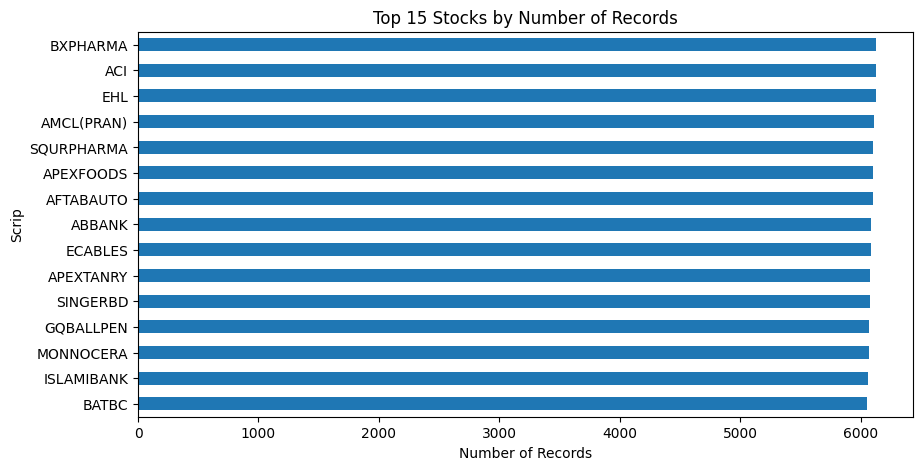

In [11]:
top_stocks = df["Scrip"].value_counts().head(15)

plt.figure(figsize=(10, 5))
top_stocks.sort_values().plot(kind="barh")

plt.title("Top 15 Stocks by Number of Records")
plt.xlabel("Number of Records")
plt.show()

# Single Stock price prediction

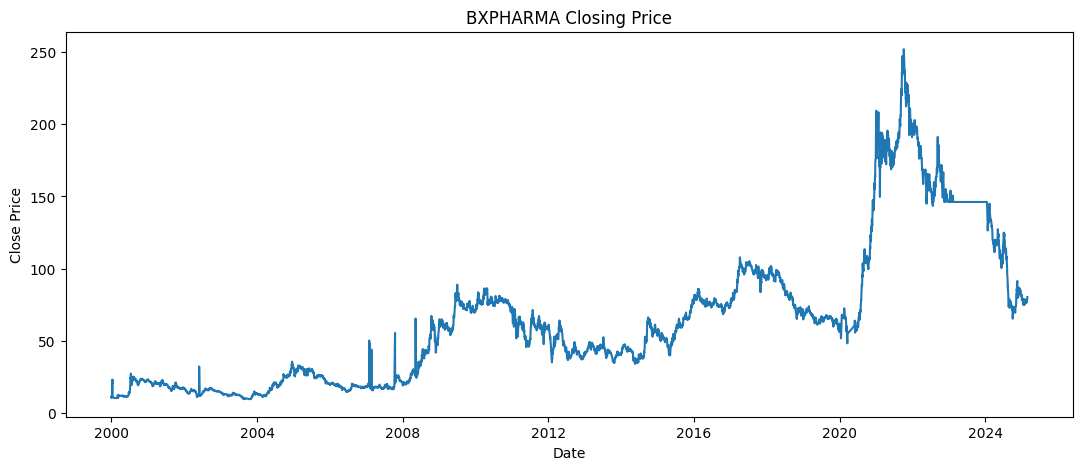

In [12]:
stock = "BXPHARMA"

data = df[df["Scrip"] == stock].copy()
data = data.sort_values("Date")

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Close"])

plt.title(f"{stock} Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

# Volume

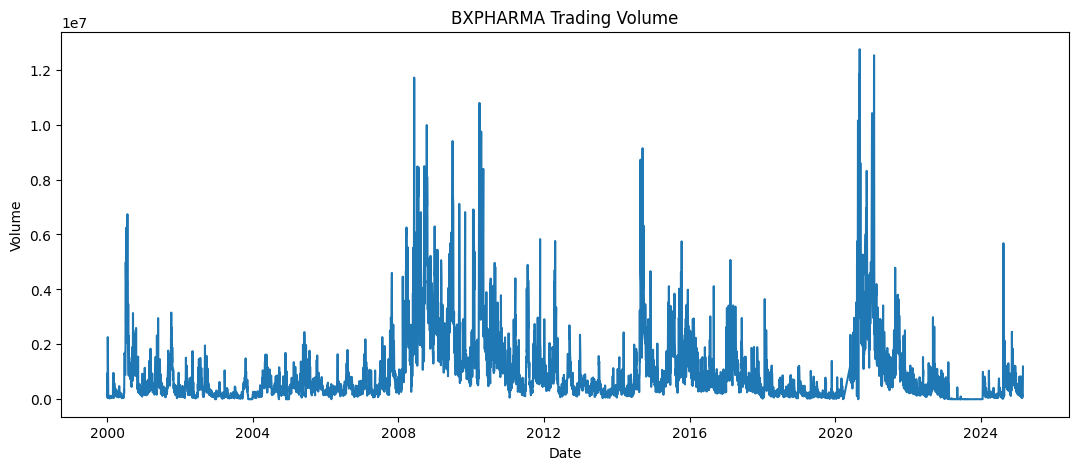

In [13]:
plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Volume"])

plt.title(f"{stock} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

# Daily return

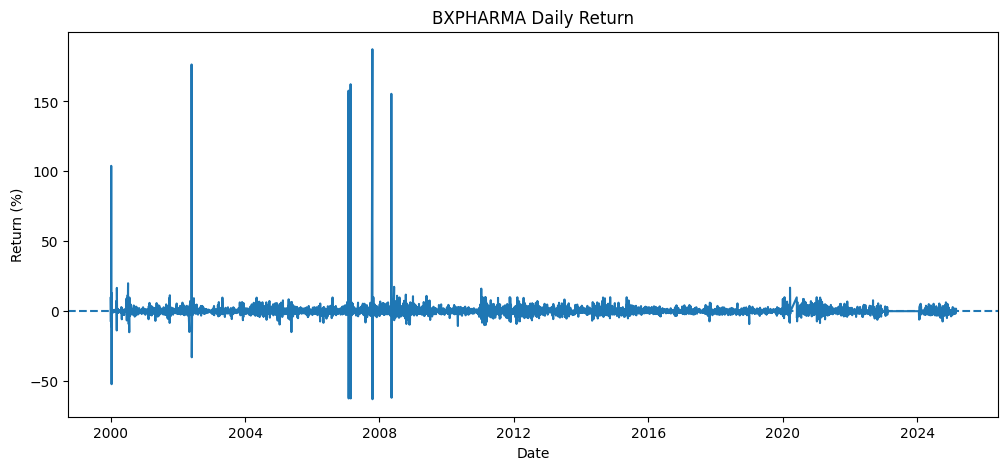

In [14]:
data["Return"] = data["Close"].pct_change() * 100

plt.figure(figsize=(12, 5))
plt.plot(data["Date"], data["Return"])

plt.axhline(0, linestyle="--")

plt.title(f"{stock} Daily Return")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.show()

# Return distribution

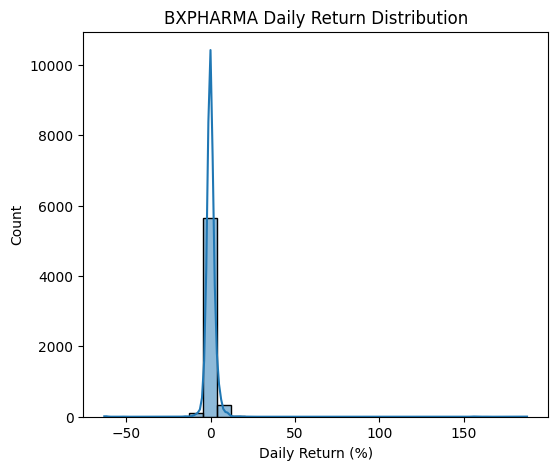

In [15]:
plt.figure(figsize=(6, 5))

sns.histplot(data["Return"].dropna(),bins=30,kde=True)

plt.title(f"{stock} Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.show()

# Rolling volatility

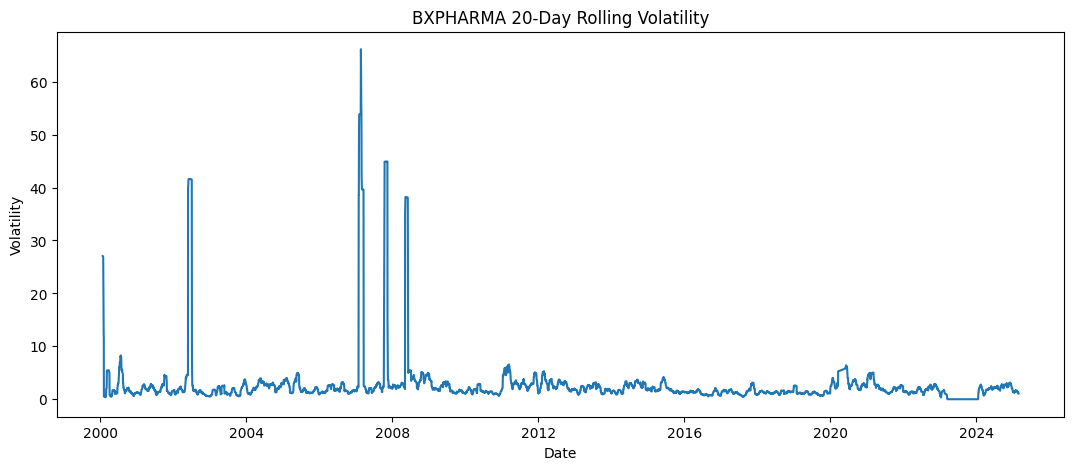

In [16]:
data["Volatility"] = data["Return"].rolling(20).std()

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Volatility"])

plt.title(f"{stock} 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

# Volume vs return

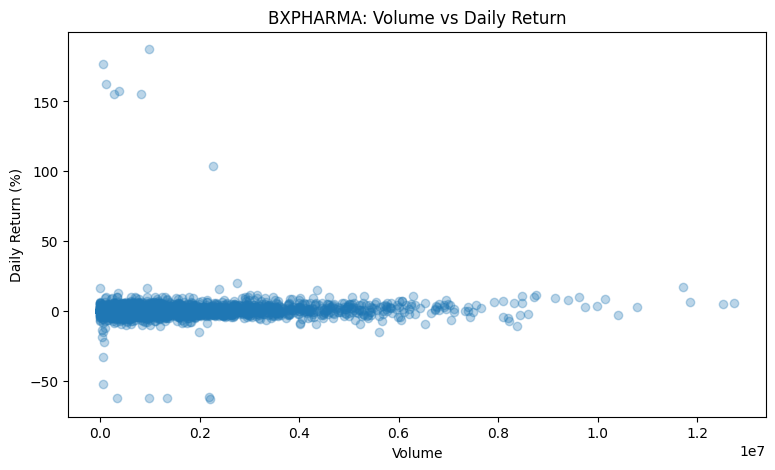

In [17]:
plt.figure(figsize=(9, 5))

plt.scatter(data["Volume"],data["Return"],alpha=0.3)

plt.xlabel("Volume")
plt.ylabel("Daily Return (%)")
plt.title(f"{stock}: Volume vs Daily Return")

plt.show()

# High-Low range

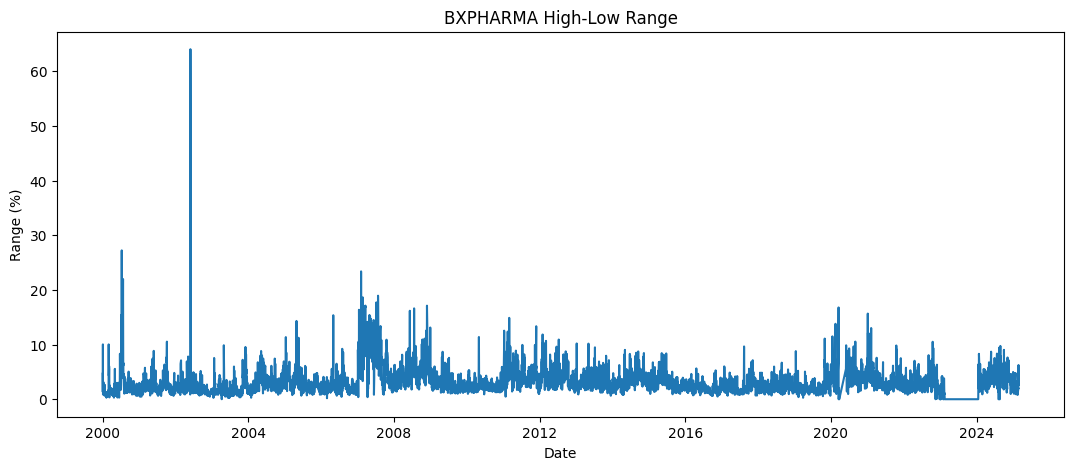

In [18]:
data["Range"] = ((data["High"] - data["Low"]) / data["Close"]) * 100

plt.figure(figsize=(13, 5))
plt.plot(data["Date"], data["Range"])

plt.title(f"{stock} High-Low Range")
plt.xlabel("Date")
plt.ylabel("Range (%)")
plt.show()

# OHLC Price Trend

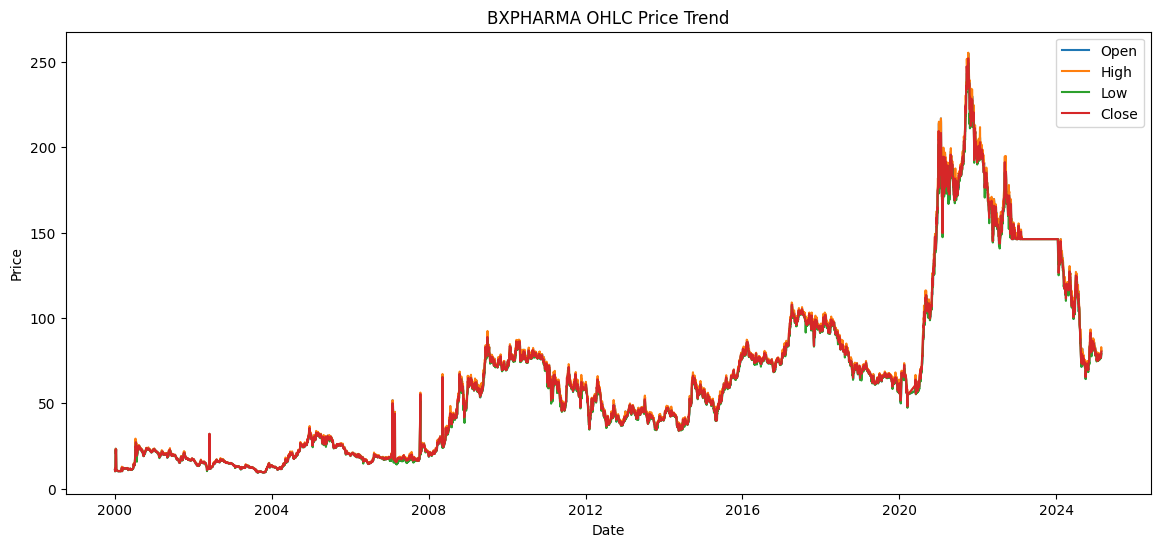

In [19]:
stock = "BXPHARMA"

data = df[df["Scrip"] == stock].copy()
data = data.sort_values("Date")

plt.figure(figsize=(14, 6))

plt.plot(data["Date"], data["Open"], label="Open")
plt.plot(data["Date"], data["High"], label="High")
plt.plot(data["Date"], data["Low"], label="Low")
plt.plot(data["Date"], data["Close"], label="Close")

plt.title(f"{stock} OHLC Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

# Different Stocks  Volatility Comparison

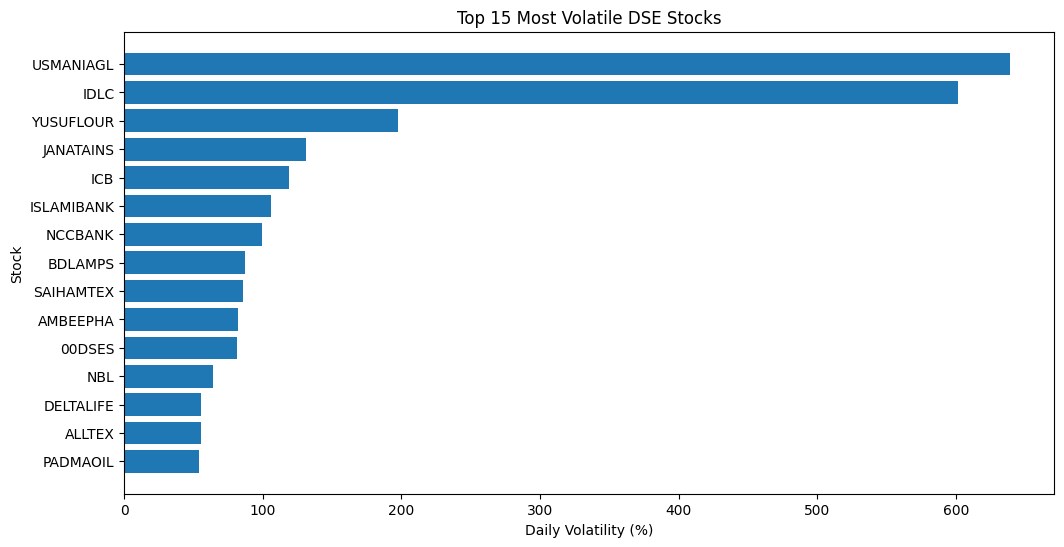

In [20]:
df["Return"] = df.groupby("Scrip")["Close"].pct_change()
volatility = (df.groupby("Scrip")["Return"].std().sort_values(ascending=False))

top_volatility = volatility.head(15).sort_values()

plt.figure(figsize=(12, 6))

plt.barh(top_volatility.index,top_volatility.values * 100)

plt.title("Top 15 Most Volatile DSE Stocks")
plt.xlabel("Daily Volatility (%)")
plt.ylabel("Stock")

plt.show()

# Return Autocorrelation

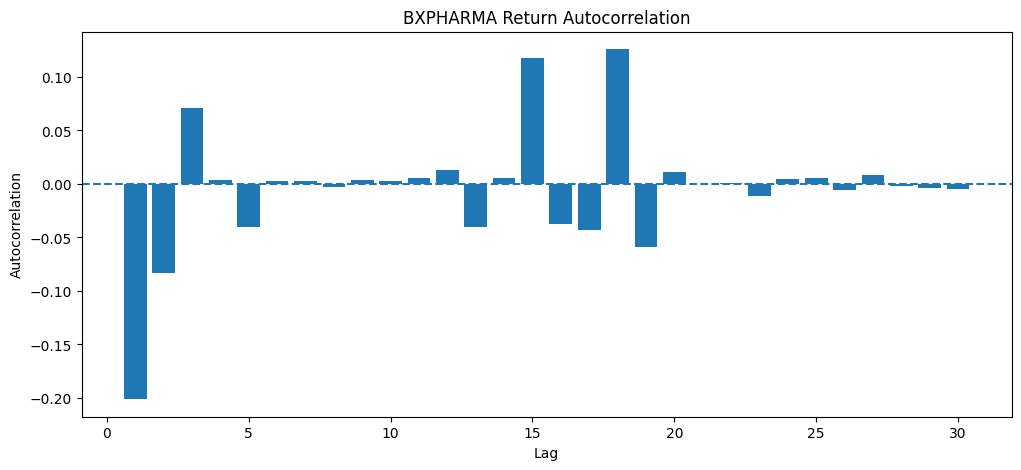

In [21]:
data["Return"] = data["Close"].pct_change()

autocorrelation = []

for lag in range(1, 31):
    value = data["Return"].autocorr(lag=lag)
    autocorrelation.append(value)

plt.figure(figsize=(12, 5))

plt.bar(range(1, 31), autocorrelation)

plt.axhline(0, linestyle="--")

plt.title(f"{stock} Return Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

# CoRelational Heatmap 

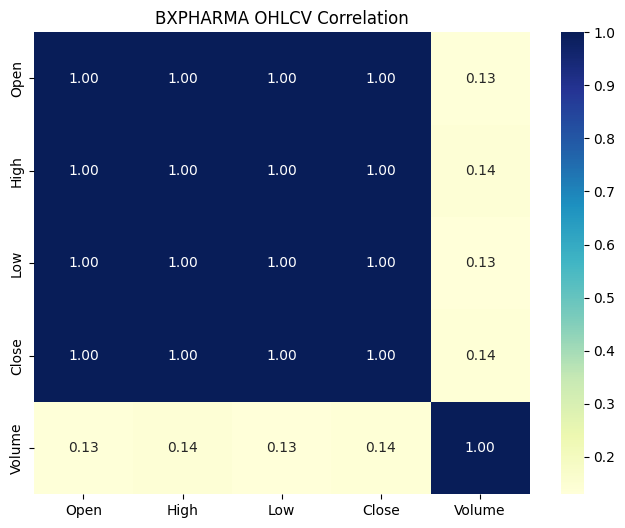

In [22]:
cols = ["Open", "High", "Low", "Close", "Volume"]

plt.figure(figsize=(8, 6))

sns.heatmap(data[cols].corr(),annot=True,cmap="YlGnBu",fmt=".2f")

plt.title(f"{stock} OHLCV Correlation")
plt.show()

# **Feature Engineering**

In [23]:
df = df.sort_values(["Scrip", "Date"]).copy()

Daily Return

In [24]:
df["Return"] = df.groupby("Scrip")["Close"].pct_change()

Lag Features

In [25]:
df["Close_Lag1"] = df.groupby("Scrip")["Close"].shift(1)
df["Close_Lag2"] = df.groupby("Scrip")["Close"].shift(2)
df["Close_Lag3"] = df.groupby("Scrip")["Close"].shift(3)
df["Close_Lag5"] = df.groupby("Scrip")["Close"].shift(5)

df["Return_Lag1"] = df.groupby("Scrip")["Return"].shift(1)
df["Return_Lag2"] = df.groupby("Scrip")["Return"].shift(2)
df["Return_Lag5"] = df.groupby("Scrip")["Return"].shift(5)

Moving Average

In [26]:
df["SMA_5"] = df.groupby("Scrip")["Close"].rolling(5).mean().reset_index(level=0, drop=True)

df["SMA_20"] = df.groupby("Scrip")["Close"].rolling(20).mean().reset_index(level=0, drop=True)

df["SMA_50"] = df.groupby("Scrip")["Close"].rolling(50).mean().reset_index(level=0, drop=True)

Exponential Moving Average

In [27]:
df["EMA_12"] = df.groupby("Scrip")["Close"].transform(lambda x: x.ewm(span=12).mean())

df["EMA_26"] = df.groupby("Scrip")["Close"].transform(lambda x: x.ewm(span=26).mean())

Rolling Volatility

In [28]:
df["Volatility_5"] = (df.groupby("Scrip")["Return"].transform(lambda x: x.rolling(5).std()))

df["Volatility_20"] = (df.groupby("Scrip")["Return"].transform(lambda x: x.rolling(20).std()))

Price Range

In [29]:
df["Price_Range"] = ((df["High"] - df["Low"]) / df["Close"])

Volume Features

In [30]:
df["Volume_Change"] = (df.groupby("Scrip")["Volume"].pct_change())
df["Volume_SMA_20"] = (df.groupby("Scrip")["Volume"].transform(lambda x: x.rolling(20).mean()))

# Dataset Shape


In [31]:
df.shape

(1381571, 25)

In [32]:
def indicators(stock):

   
    if len(stock) < 35:
        stock["RSI"] = float("nan")
        stock["MACD"] = float("nan")
        stock["MACD_Signal"] = float("nan")
        stock["MACD_Hist"] = float("nan")
        stock["BB_High"] = float("nan")
        stock["BB_Low"] = float("nan")
        stock["BB_Middle"] = float("nan")
        stock["ATR"] = float("nan")
        stock["ROC"] = float("nan")

        return stock

    # RSI
    stock["RSI"] = RSIIndicator(
        stock["Close"], window=14
    ).rsi()

    # MACD
    macd = MACD(stock["Close"])

    stock["MACD"] = macd.macd()
    stock["MACD_Signal"] = macd.macd_signal()
    stock["MACD_Hist"] = macd.macd_diff()

    # Bollinger Bands
    bb = BollingerBands(
        stock["Close"],
        window=20
    )

    stock["BB_High"] = bb.bollinger_hband()
    stock["BB_Low"] = bb.bollinger_lband()
    stock["BB_Middle"] = bb.bollinger_mavg()

    # ATR
    atr = AverageTrueRange(
        stock["High"],
        stock["Low"],
        stock["Close"],
        window=14
    )

    stock["ATR"] = atr.average_true_range()

    # ROC
    stock["ROC"] = ROCIndicator(
        stock["Close"],
        window=12
    ).roc()

    return stock

In [33]:
df = df.sort_values(["Scrip", "Date"])

df = df.groupby("Scrip", group_keys=False).apply(indicators)

df = df.reset_index(drop=True)

C:\Users\INTEL\AppData\Local\Temp\ipykernel_12760\2407249385.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Scrip", group_keys=False).apply(indicators)


In [34]:
df.isnull().sum().sort_values(ascending=False)

SMA_50           21052
MACD_Hist        14252
MACD_Signal      14252
MACD             10852
Volatility_20     8727
BB_Middle         8302
BB_Low            8302
BB_High           8302
Volume_SMA_20     8301
SMA_20            8301
RSI               5752
ROC               5327
Return_Lag5       2709
Volatility_5      2265
Close_Lag5        2265
SMA_5             1819
Close_Lag3        1370
Return_Lag2       1370
Close_Lag2         920
Return_Lag1        920
Volume_Change      569
Return             464
Close_Lag1         464
ATR                227
Scrip                0
Date                 0
Close                0
Low                  0
High                 0
Open                 0
Volume               0
Price_Range          0
EMA_26               0
EMA_12               0
dtype: int64

## Handling Nan values

In [35]:
df = df.dropna().reset_index(drop=True)

In [36]:
df.isnull().sum().sort_values(ascending=False)

Date             0
Scrip            0
Open             0
High             0
Low              0
Close            0
Volume           0
Return           0
Close_Lag1       0
Close_Lag2       0
Close_Lag3       0
Close_Lag5       0
Return_Lag1      0
Return_Lag2      0
Return_Lag5      0
SMA_5            0
SMA_20           0
SMA_50           0
EMA_12           0
EMA_26           0
Volatility_5     0
Volatility_20    0
Price_Range      0
Volume_Change    0
Volume_SMA_20    0
RSI              0
MACD             0
MACD_Signal      0
MACD_Hist        0
BB_High          0
BB_Low           0
BB_Middle        0
ATR              0
ROC              0
dtype: int64

In [37]:
before = len(df)

df = df.dropna().reset_index(drop=True)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 1360421
Rows after: 1360421
Rows removed: 0


In [38]:
print("Total NaN:", df.isna().sum().sum())

Total NaN: 0


In [39]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Scrip", "Date"]).reset_index(drop=True)

Next day's Close

In [40]:
df["Next_Close"] = (df.groupby("Scrip")["Close"].shift(-1))

Direction making

In [42]:
df["Direction"] = 0

df.loc[df["Next_Close"] > df["Close"], "Direction"] = 1

df.loc[df["Next_Close"] < df["Close"], "Direction"] = -1

# Remove Last row

In [45]:
df = df.dropna(subset=["Next_Close"]).reset_index(drop=True)

# Checking The dataset


In [48]:
df[["Scrip", "Date", "Close", "Next_Close", "Direction"]].head(20)


,Scrip,Date,Close,Next_Close,Direction
0,00DS30,2013-04-11,1322.06,1338.45,1
1,00DS30,2013-04-15,1338.45,1318.51,-1
2,00DS30,2013-04-16,1318.51,1321.18,1
3,00DS30,2013-04-17,1321.18,1322.00,1
4,00DS30,2013-04-18,1322.00,1306.58,-1
5,00DS30,2013-04-21,1306.58,1305.59,-1
6,00DS30,2013-04-22,1305.59,1307.46,1
7,00DS30,2013-04-23,1307.46,1307.35,-1
8,00DS30,2013-04-24,1307.35,1308.37,1
9,00DS30,2013-04-25,1308.37,1288.02,-1


In [49]:
df["Direction"].value_counts()

Direction
-1    640105
 1    527362
 0    192529
Name: count, dtype: int64

In [51]:
df = df.drop(columns=["Next_Close"])

## **Time-Series Split.**

In [53]:
# Dataset sorting
df = df.sort_values("Date").reset_index(drop=True)

# Finding the 80% of this dataset and performing Train and test

In [54]:
split_point = int(len(df) * 0.8)

train_data = df.iloc[:split_point].copy()
test_data = df.iloc[split_point:].copy()

In [55]:
print("Train:", train_data.shape)
print("Test :", test_data.shape)

print("\nTrain period:")
print(train_data["Date"].min(), "to", train_data["Date"].max())

print("\nTest period:")
print(test_data["Date"].min(), "to", test_data["Date"].max())

Train: (1087996, 35)
Test : (272000, 35)

Train period:
2000-03-11 00:00:00 to 2022-03-08 00:00:00

Test period:
2022-03-08 00:00:00 to 2025-02-25 00:00:00


## **Dataset Spliting**

In [56]:
X = train_data.drop(columns=["Direction", "Date", "Scrip"])
y = train_data["Direction"]

Creating Time-Series CV

In [58]:
tscv = TimeSeriesSplit(n_splits=5)

Check the Fold

In [60]:
for fold_number, (train_index, val_index) in enumerate(tscv.split(X), start=1):

    print(f"\n--- Fold {fold_number} ---")

    print("Training rows:", train_index[0], "to", train_index[-1])
    print("Validation rows:", val_index[0], "to", val_index[-1])


--- Fold 1 ---
Training rows: 0 to 181335
Validation rows: 181336 to 362667

--- Fold 2 ---
Training rows: 0 to 362667
Validation rows: 362668 to 543999

--- Fold 3 ---
Training rows: 0 to 543999
Validation rows: 544000 to 725331

--- Fold 4 ---
Training rows: 0 to 725331
Validation rows: 725332 to 906663

--- Fold 5 ---
Training rows: 0 to 906663
Validation rows: 906664 to 1087995


In [66]:
x_train = train_data.drop(columns=["Direction", "Date", "Scrip"])
y_train = train_data["Direction"]

## **Applying Boruta**

In [79]:
# 1. Take a smaller sample for Boruta
boruta_sample = (train_data.sample(n=100000, random_state=42).sort_values("Date"))

# 2. Separate features and target
x_boruta = boruta_sample.drop(columns=["Direction", "Date", "Scrip"])

y_boruta = boruta_sample["Direction"]


# 3. Handle infinity values
x_boruta = x_boruta.replace([np.inf, -np.inf],np.nan)

# 4. Remove rows containing NaN
valid_rows = x_boruta.notna().all(axis=1)

x_boruta = x_boruta.loc[valid_rows]
y_boruta = y_boruta.loc[valid_rows]


# 5. Check the data
print("Rows for Boruta:", len(x_boruta))
print("Columns:", x_boruta.shape[1])
print("NaN values:", x_boruta.isna().sum().sum())
print("Infinity values:", np.isinf(x_boruta).sum().sum())


# 6. Random Forest for Boruta
rf = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1,class_weight="balanced")

# 7. Create Boruta
boruta = BorutaPy(estimator=rf,n_estimators="auto",verbose=2,random_state=42)

# 8. Run Boruta
boruta.fit(x_boruta.values,y_boruta.values)

# 9. Get confirmed features
selected_features = x_boruta.columns[boruta.support_]

print("\nConfirmed Features:")
print(selected_features.tolist())


# 10. Get tentative features
tentative_features = x_boruta.columns[boruta.support_weak_]

print("\nTentative Features:")
print(tentative_features.tolist())

Rows for Boruta: 99951
Columns: 32
NaN values: 0
Infinity values: 0
Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	16
Tentative: 	3
Rejected: 	13
Iteration: 	9 / 100
Confirmed: 	16
Tentative: 	3
Rejected: 	13
Iteration: 	10 / 100
Confirmed: 	16
Tentative: 	3
Rejected: 	13
Iteration: 	11 / 100
Confirmed: 	16
Tentative: 	3
Rejected: 	13
Iteration: 	12 / 100
Confirmed: 	16
Tentative: 	3
Rejected: 	13
Iteration: 	13 / 100
Confirmed: 	16
Tentative: 	3
Rejected: 	13
Iteration: 	14 / 100
Confirmed: 	16
Tentative: 	3
Rejected: 	13
Iteration: 	15 / 100
Confirmed: 	16
Tentative: 	3
Re

In [186]:
print("TRAIN")
print(train_data.groupby("Direction")["Close"].describe())

print("\nTEST")
print(test_data.groupby("Direction")["Close"].describe())

TRAIN
              count        mean         std       min        25%        50%  \
Direction                                                                     
-1         528685.0   99.745017  358.823463  0.154491  13.600000  27.100000   
 0         112780.0   31.819719  130.362844  0.042299   6.900000  11.538462   
 1         446531.0  107.183282  400.832542  0.004381  13.071895  26.448083   

               75%      max  
Direction                    
-1         62.7000  8671.56  
 0         23.0000  5583.01  
 1         61.9001  8593.38  

TEST
              count        mean         std  min   25%       50%   75%     max
Direction                                                                     
-1         111420.0  157.410312  532.021927  2.3  19.8  38.50000  86.2  8941.2
 0          79749.0   84.389968  327.742460  2.3   9.7  22.47619  49.3  8399.9
 1          80831.0  178.185325  590.862401  2.2  20.7  40.00000  93.0  8812.2


## Understanding Boruta Though the plot

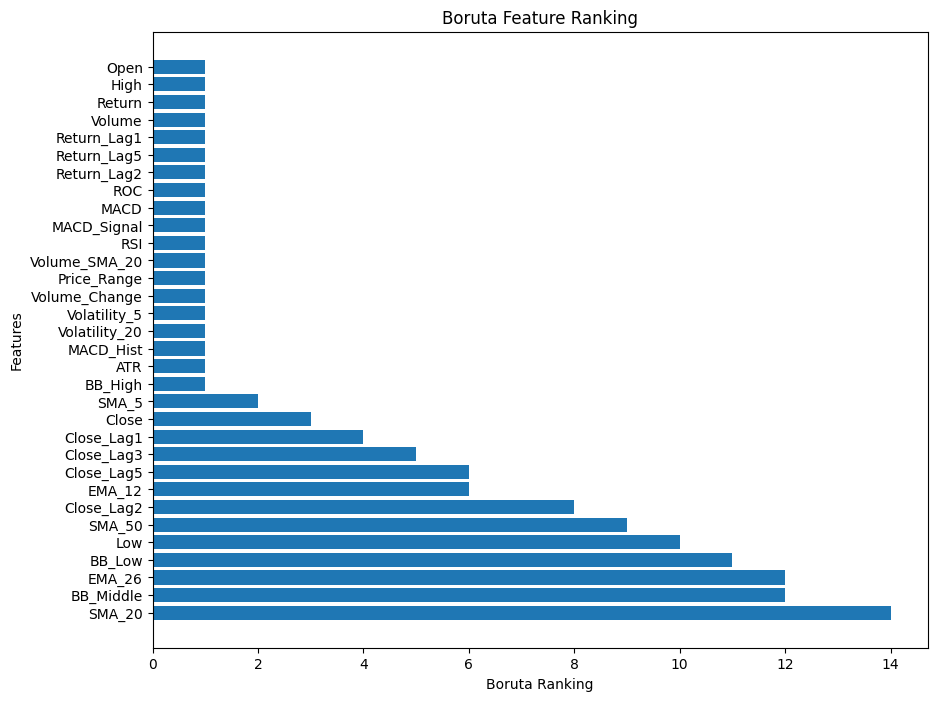

In [84]:
feature_ranking = pd.DataFrame({"Feature": x_boruta.columns,"Ranking": boruta.ranking_})

feature_ranking = feature_ranking.sort_values("Ranking")

plt.figure(figsize=(10, 8))

plt.barh(feature_ranking["Feature"],feature_ranking["Ranking"])

plt.xlabel("Boruta Ranking")
plt.ylabel("Features")
plt.title("Boruta Feature Ranking")

plt.gca().invert_yaxis()

plt.show()

In [123]:
# Training data
xtrain = train_data.drop(columns=["Direction", "Date", "Scrip"])
ytrain = train_data["Direction"]

# Testing data
xtest = test_data.drop(columns=["Direction", "Date", "Scrip"])
ytest = test_data["Direction"]

In [117]:
# Get the 19 features selected by Boruta
selected_features = x_boruta.columns[boruta.support_]

print("Selected features:", selected_features.tolist())
print("Number of selected features:", len(selected_features))

Selected features: ['Open', 'High', 'Volume', 'Return', 'Return_Lag1', 'Return_Lag2', 'Return_Lag5', 'Volatility_5', 'Volatility_20', 'Price_Range', 'Volume_Change', 'Volume_SMA_20', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_High', 'ATR', 'ROC']
Number of selected features: 19


In [124]:
# Keep only the 19 Boruta-selected features
xtrain_selected = xtrain[selected_features].copy()
xtest_selected = xtest[selected_features].copy()

# Check shapes
print("X_train_selected:", xtrain_selected.shape)
print("y_train:", y_train.shape)

print("X_test_selected:", xtest_selected.shape)
print("y_test:", ytest.shape)

X_train_selected: (1087996, 19)
y_train: (1087996,)
X_test_selected: (272000, 19)
y_test: (272000,)


In [ ]:
xtrain_selected = xtrain_selected.replace([np.inf, -np.inf], np.nan)
xtest_selected = xtest_selected.replace([np.inf, -np.inf], np.nan)

In [146]:
xtrain_selected['Volume_Change'] = xtrain_selected['Volume_Change'].fillna(xtrain_selected['Volume_Change'].median())

In [ ]:
xtest_selected = xtest_selected.replace([np.inf, -np.inf], np.nan)

xtest_selected["Volume_Change"] = (xtest_selected["Volume_Change"].fillna(xtrain_selected["Volume_Change"].median()))

## Model Train and Test And Evaluation

# Performing LogisticRegression

In [150]:
lr= LogisticRegression(C=1.0,solver="lbfgs",max_iter=10000,class_weight="balanced",random_state=42)

model_lr= lr.fit(xtrain_selected,ytrain)

#Training Score 
print("Training Score : ", model_lr.score(xtrain_selected,ytrain)*100)

#Test Score 
print("Testing Score : ", model_lr.score(xtest_selected,ytest)*100)


Training Score :  41.079746616715504
Testing Score :  31.00294117647059


# Evaluation

Accuracy Score for LogisticRegression :  31.00294117647059
Classification Report               precision    recall  f1-score   support

          -1       0.57      0.00      0.00    111420
           0       0.79      0.05      0.09     79749
           1       0.30      0.99      0.46     80831

    accuracy                           0.31    272000
   macro avg       0.55      0.35      0.19    272000
weighted avg       0.55      0.31      0.16    272000



<Axes: >

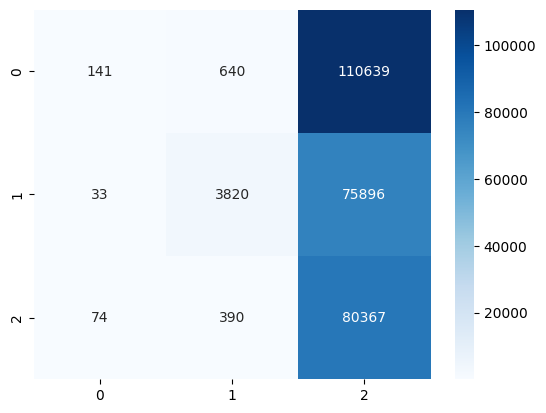

In [158]:
# Prediction
y_pred_lr = lr.predict(xtest_selected)

# accuracy score 
acc_lr = accuracy_score(ytest,y_pred_lr)
print("Accuracy Score for LogisticRegression : ",acc_lr*100)


#Classification Report
class_rep_lr = classification_report(ytest,y_pred_lr)
print("Classification Report", class_rep_lr)

# Confusion Matrix
con_max_lr = confusion_matrix(ytest,y_pred_lr)

#heatmap 
sns.heatmap(con_max_lr,annot=True,fmt = 'd', cmap="Blues")


#  Performing Random Forest 

In [162]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model_rf = rf.fit(xtrain_selected,ytrain)

#Training Score 
print("Training Score For Random Forest : ", model_rf.score(xtrain_selected,ytrain)*100)

#Test Score 
print("Testing Score For Random Forest : ", model_rf.score(xtest_selected,ytest)*100)

Training Score For Random Forest :  46.02912143059349
Testing Score For Random Forest :  58.81360294117647


# Evaluation

Accuracy Score for Random Forest :  58.81360294117647
Classification Report               precision    recall  f1-score   support

          -1       0.57      0.00      0.00    111420
           0       0.79      0.05      0.09     79749
           1       0.30      0.99      0.46     80831

    accuracy                           0.31    272000
   macro avg       0.55      0.35      0.19    272000
weighted avg       0.55      0.31      0.16    272000



<Axes: >

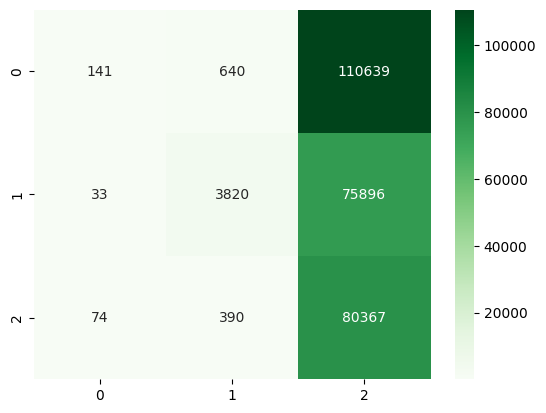

In [163]:
# Prediction
y_pred_rf = rf.predict(xtest_selected)

# accuracy score 
acc_rf = accuracy_score(ytest,y_pred_rf)
print("Accuracy Score for Random Forest : ",acc_rf*100)


#Classification Report
class_rep_rf = classification_report(ytest,y_pred_rf)
print("Classification Report", class_rep_lr)

# Confusion Matrix
con_max_rf = confusion_matrix(ytest,y_pred_rf)

#heatmap 
sns.heatmap(con_max_lr,annot=True,fmt = 'd', cmap="Greens")


# Performing Decision Tree Classifier

In [171]:
dt = DecisionTreeClassifier(
    criterion="gini",
    splitter="best",
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=None,
    class_weight="balanced",
    ccp_alpha=0.0001,
    random_state=42
)

model_dt = dt.fit(xtrain_selected, ytrain)

print("Training Score:", model_dt.score(xtrain_selected, ytrain) * 100)
print("Testing Score:", model_dt.score(xtest_selected, ytest) * 100)


Training Score: 43.96119103379056
Testing Score: 56.67904411764706


# Evaluation

Accuracy Score for Decision Tree Classifier :  56.67904411764706
Classification Report               precision    recall  f1-score   support

          -1       0.56      0.46      0.50    111420
           0       0.68      0.88      0.76     79749
           1       0.43      0.41      0.42     80831

    accuracy                           0.57    272000
   macro avg       0.55      0.58      0.56    272000
weighted avg       0.55      0.57      0.55    272000



<Axes: >

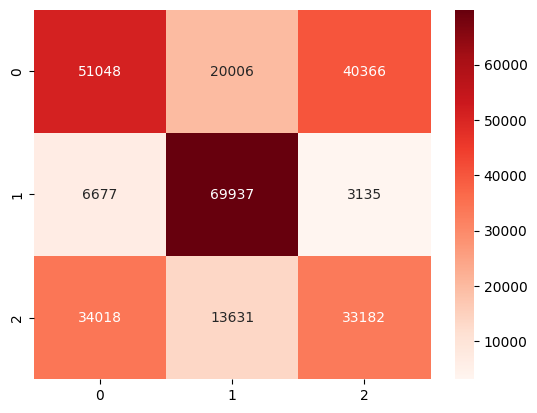

In [172]:
# Prediction
y_pred_dt = dt.predict(xtest_selected)

# accuracy score 
acc_dt = accuracy_score(ytest,y_pred_dt)
print("Accuracy Score for Decision Tree Classifier : ",acc_dt*100)


#Classification Report
class_rep_dt = classification_report(ytest,y_pred_dt)
print("Classification Report", class_rep_dt)

# Confusion Matrix
con_max_dt = confusion_matrix(ytest,y_pred_dt)

#heatmap 
sns.heatmap(con_max_dt,annot=True,fmt = 'd', cmap="Reds")


# Performing XGBoost